In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [36]:
df = pd.read_csv('C:\\Users\\subham\\Desktop\\TekWorks\\12 March\\customer_churn.csv')
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [37]:
# Check for missing values
print(df.isnull().sum())

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64


In [38]:
df.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [40]:
df['churn'].value_counts()

churn
1    517
0    483
Name: count, dtype: int64

### Data Preprocessing

In [41]:
# Handle the missing values in the dataset
df['income'].value_counts()

income
254852.478291    20
53051.954538      1
39677.744822      1
51883.646802      1
47403.922636      1
                 ..
43317.462179      1
73693.582186      1
42157.099593      1
43697.197744      1
44407.502719      1
Name: count, Length: 932, dtype: int64

In [42]:
# Find the mean median mode of the income column
mean_income = df['income'].mean()
median_income = df['income'].median()
mode_income = df['income'].mode()[0]
print("Mean Income:", mean_income)
print("Median Income:", median_income)
print("Mode Income:", mode_income)

Mean Income: 55354.41751318089
Median Income: 51298.8468120935
Mode Income: 254852.4782908424


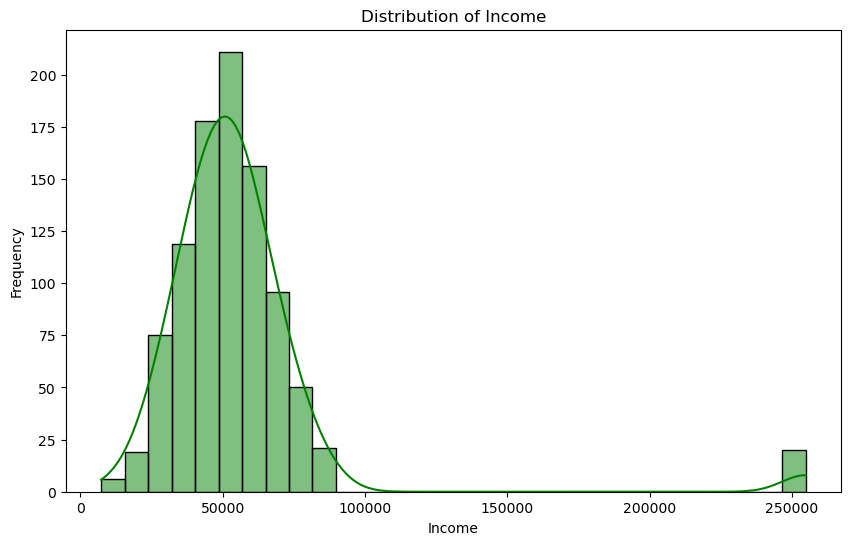

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df['income'], bins=30, kde=True, color='green')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

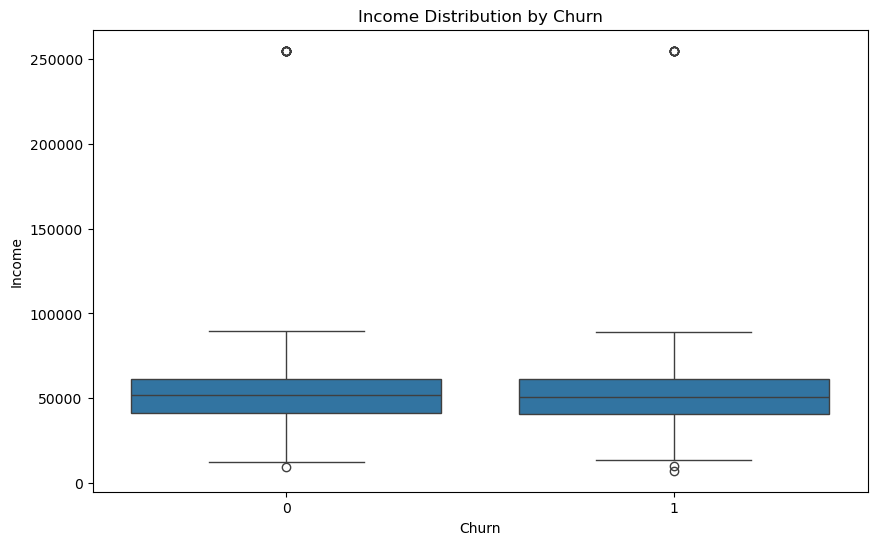

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='income', data=df)
plt.title('Income Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Income')
plt.show()

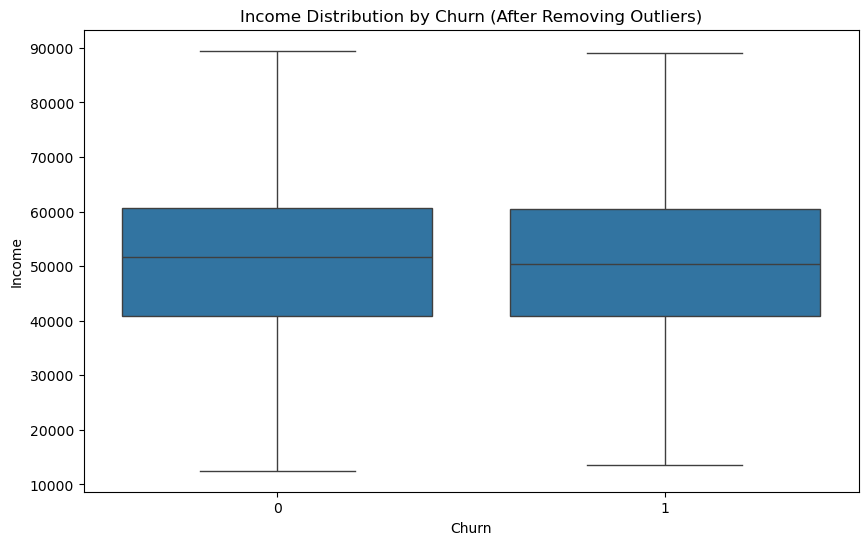

In [45]:
# Remove Outliers using IQR method
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='income', data=df)
plt.title('Income Distribution by Churn (After Removing Outliers)')
plt.xlabel('Churn')
plt.ylabel('Income')
plt.show()

In [46]:
#  Find median for the income column after removing outliers
median_income = df['income'].median()
median_income

50891.36602950997

In [47]:
median_income = round(median_income, 7)
median_income

50891.3660295

In [48]:
# Fill the income column using 
df['income'].fillna(median_income, inplace=True)
df

C:\Windows\Temp\ipykernel_19516\1695062200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(median_income, inplace=True)


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
6,38,75307.124526,NaN,40,141.636341,84,96,1,Female,North,0
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [49]:
df.isnull().sum()

age                       0
income                    0
credit_score             45
transactions_month        0
avg_purchase_value       47
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

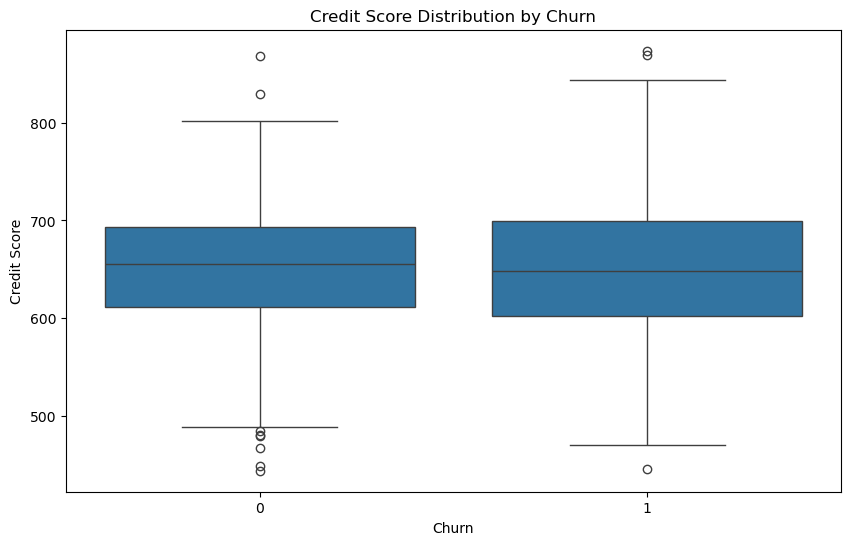

In [50]:
# Check Outliers using for credit score column
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title('Credit Score Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Credit Score')
plt.show()

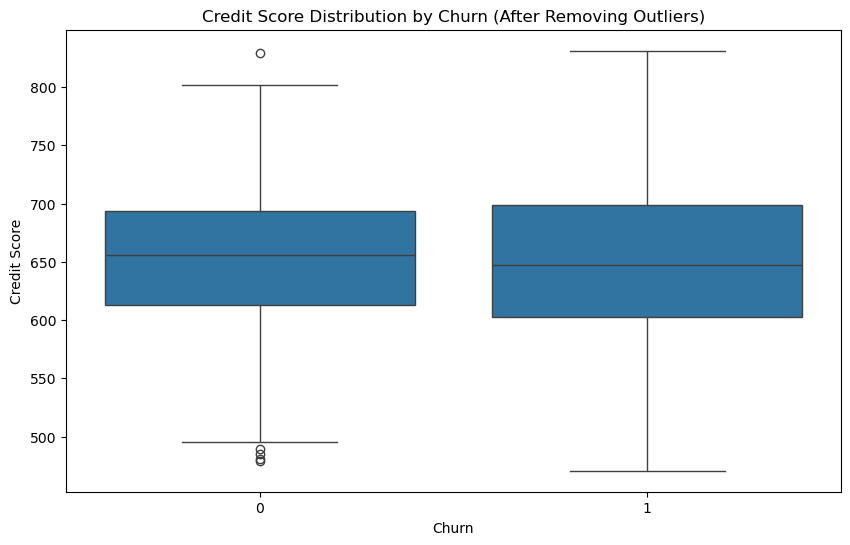

In [51]:
# Remove the outliers using IQR method for credit score column
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['credit_score'] >= lower_bound) & (df['credit_score'] <= upper_bound)]


plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title('Credit Score Distribution by Churn (After Removing Outliers)')
plt.xlabel('Churn')
plt.ylabel('Credit Score')
plt.show()  

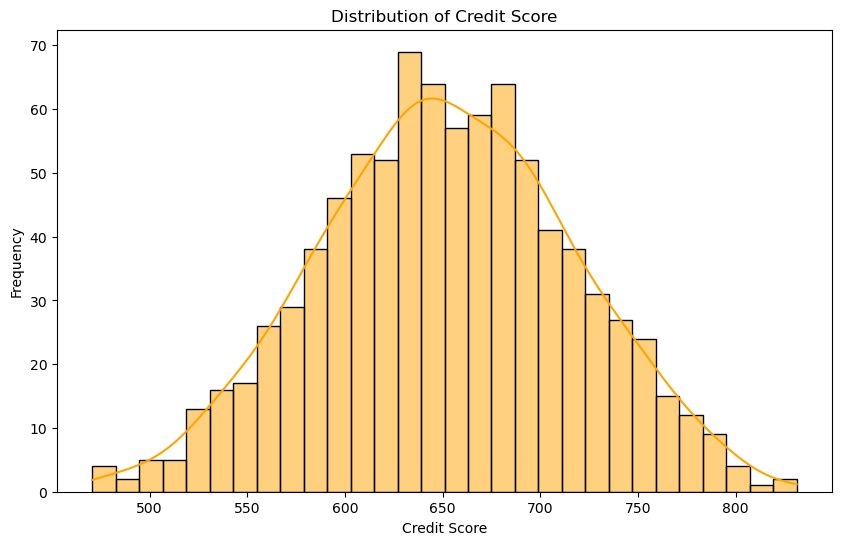

In [52]:
# Check the distributing of credit score column
plt.figure(figsize=(10, 6))
sns.histplot(df['credit_score'], bins=30, kde=True, color='orange')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [53]:
# Find the mean of credit score column
mean_credit_score = df['credit_score'].mean()
mean_credit_score

np.float64(651.5158553240933)

In [54]:
mean_credit_score = round(mean_credit_score, 7)
mean_credit_score

np.float64(651.5158553)

In [55]:
# Handle missing value with mean value in the credit score column
df['credit_score'].fillna(mean_credit_score, inplace=True)
df

C:\Windows\Temp\ipykernel_19516\3125796806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(mean_credit_score, inplace=True)
C:\Windows\Temp\ipykernel_19516\3125796806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_score'].fillna(mean_credit_score, inplace=True)


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,Male,West,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,Male,West,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [56]:
df.isnull().sum()

age                       0
income                    0
credit_score              0
transactions_month        0
avg_purchase_value       43
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

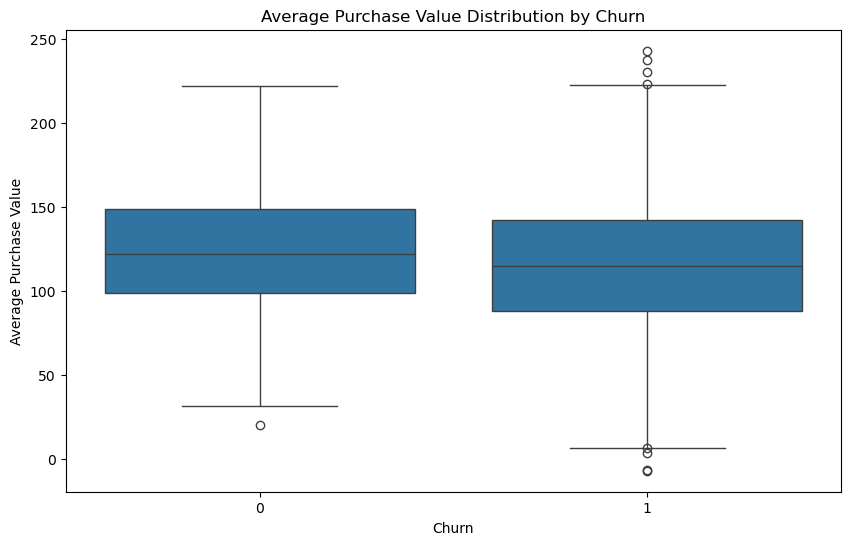

In [57]:
# Check for outlier for avg_purchase_value column
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='avg_purchase_value', data=df)
plt.title('Average Purchase Value Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Purchase Value')
plt.show()

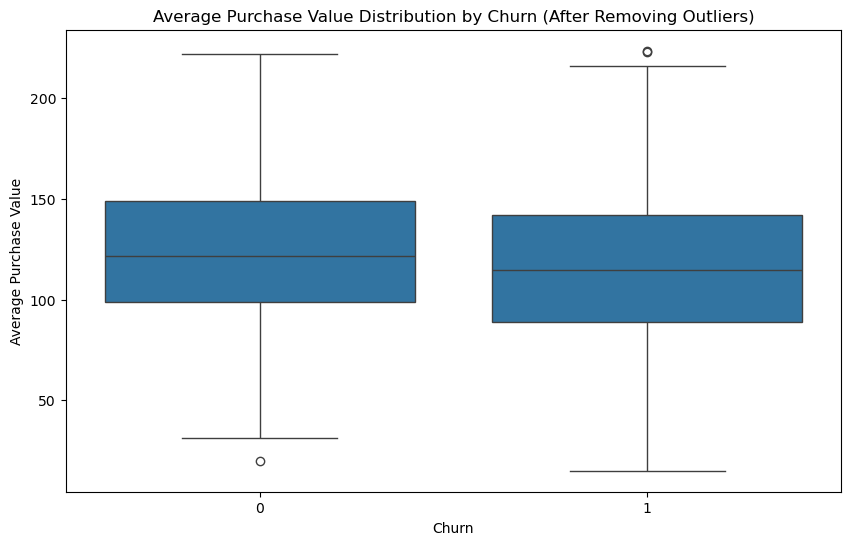

In [58]:
# Remove the Outliers using the IQR method for avg_purchase_value column
Q1 = df['avg_purchase_value'].quantile(0.25)
Q3 = df['avg_purchase_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['avg_purchase_value'] >= lower_bound) & (df['avg_purchase_value'] <= upper_bound)]


plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='avg_purchase_value', data=df)
plt.title('Average Purchase Value Distribution by Churn (After Removing Outliers)')
plt.xlabel('Churn')
plt.ylabel('Average Purchase Value')
plt.show()

In [59]:
# Find the median of the avg_purchase_value column
median_avg_purchase_value = df['avg_purchase_value'].median()
median_avg_purchase_value

119.24866736331325

In [60]:
median_avg_purchase_value = round(median_avg_purchase_value, 7)
median_avg_purchase_value

119.2486674

In [61]:
df.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824 entries, 1 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    824 non-null    int64  
 1   income                 824 non-null    float64
 2   credit_score           824 non-null    float64
 3   transactions_month     824 non-null    int64  
 4   avg_purchase_value     824 non-null    float64
 5   days_since_last_login  824 non-null    int64  
 6   tenure_months          824 non-null    int64  
 7   num_products           824 non-null    int64  
 8   gender                 824 non-null    object 
 9   region                 824 non-null    object 
 10  churn                  824 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 77.2+ KB


In [63]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(include=np.number).columns

print("Categorical Columns:", categorical_cols)

print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['gender', 'region'], dtype='object')
Numerical Columns: Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'churn'],
      dtype='object')


In [64]:
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['Female' 'Male']
Unique values in 'region': ['East' 'North' 'South' 'West']


In [65]:
# Replace the gender column values with 0 and 1
df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})
df

C:\Windows\Temp\ipykernel_19516\866801088.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})
C:\Windows\Temp\ipykernel_19516\866801088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,South,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,West,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,West,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,0,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,0,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,0,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,0,West,1


In [66]:
# Change only boolean columns value into 0 and 1
boolean_cols = df.select_dtypes(include='bool').columns
for col in boolean_cols:
    df[col] = df[col].astype(int)
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,South,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,West,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,West,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,0,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,0,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,0,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,0,West,1


In [67]:
map1={'East':0,'West':1,'North':2,'South':3}
df['region']=df['region'].map(map1)
df

C:\Windows\Temp\ipykernel_19516\369183883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['region']=df['region'].map(map1)


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,0,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,2,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,3,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,1,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,0,1,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,0,3,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,0,0,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,0,1,1


In [71]:
high_scale_cols=['income','credit_score','avg_purchase_value']
for col in high_scale_cols:
    df[col]=(df[col]-df[col].min())/(df[col].max()-df[col].min())
df

C:\Windows\Temp\ipykernel_19516\3544772437.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=(df[col]-df[col].min())/(df[col].max()-df[col].min())


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,0.526692,0.419787,41,0.570414,72,96,4,1,0,1
2,46,0.339658,0.540969,36,0.479527,155,88,3,0,2,1
3,32,0.209898,0.678376,29,0.666005,76,110,2,0,3,0
7,56,0.658844,0.742429,35,0.671623,181,71,3,0,1,1
8,36,0.485490,0.390240,33,0.375326,314,33,4,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,0.568796,0.779440,26,0.644168,120,93,4,0,1,0
996,64,0.314104,0.237530,40,0.140436,172,3,4,0,3,1
997,62,0.401799,0.631855,33,0.563296,3,52,2,0,0,0
998,35,0.627810,0.379758,49,0.275681,341,74,3,0,1,1
